# Неделя 4 — Денис + Robust Evolutionary Search (FD001) **[v2 — исправленная постановка]**

Тот же **устойчивый эволюционный поиск и official robustness check**, что в `lev_week4_robust_evolutionary_search.ipynb`, плюс метод Дениса.

### Что изменено в v2 (структурно)
- **Один источник капа RUL**: таргет на train — только `max_cycle - cycle`, без предварительного piecewise-clip при загрузке; клип задаётся **только** параметром кандидата `rul_cap` в `build_aggregated_features` (как у Лева). Убрано двойное клипание (125 + rul_cap).
- **Единая шкала исправности**: `health_coeff` и нормировка std/range по сенсорам считаются от **максимумов train**; те же опорные векторы применяются к **test** — устранён сдвиг масштаба между train и test.
- **Статические std/range**: значения делятся на train-max по столбцу → сопоставимые величины на train и test.
- **Fitness**: усилен вес зоны near-failure (`FITNESS_NEAR_COEF = 0.12` вместо 0.08).
- **Validation**: добавлена доля cut-off **0.35** для более ранних точек и ближе к official.
- **Новые пути** `*_v2` и кэш `denis_week4_robust_cache_v2` — старые CSV не перезаписываются.

Иначе: Baseline / Δ-sensor по первым `BASELINE_CYCLES`; статика после rolling-блоков.



## 1. Imports and configuration

In [1]:
import hashlib
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random_state = 42
np.random.seed(random_state)
random.seed(random_state)

DATA_DIR = Path("CMAPSSData")
OUTPUT_DIR = Path("outputs")
CACHE_DIR = OUTPUT_DIR / "denis_week4_robust_cache_v2"
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

CANDIDATE_RESULTS_CSV = OUTPUT_DIR / "denis_week4_robust_v2_all_candidate_results.csv"
GENERATION_SUMMARY_CSV = OUTPUT_DIR / "denis_week4_robust_v2_generation_summary.csv"
ROBUSTNESS_LIST_CSV = OUTPUT_DIR / "denis_week4_robust_v2_robustness_candidate_list.csv"
OFFICIAL_RESULTS_CSV = OUTPUT_DIR / "denis_week4_robust_v2_official_results.csv"
SHIFT_RESULTS_CSV = OUTPUT_DIR / "denis_week4_robust_v2_shift_results.csv"
VS_WEEK3_CSV = OUTPUT_DIR / "denis_week4_robust_v2_vs_week3_comparison.csv"
FINAL_RECOMMENDATIONS_CSV = (
    OUTPUT_DIR / "denis_week4_robust_v2_final_recommendations.csv"
)

USE_EXISTING_EVOLUTION_RESULTS = True
RUN_EVOLUTION_IF_RESULTS_MISSING = True
RUN_OFFICIAL_ROBUSTNESS_CHECK = True
USE_CACHE = True
FAST_MODE = False

allowed_rul_caps_for_final_selection = [None, 120, 125, 130, 150]
max_robustness_candidates = 25

population_size = 12
generations = 5
elite_size = 3
mutation_rate = 0.18
validation_seed = 42

search_rf_base = {"n_estimators": 140, "random_state": 42, "n_jobs": -1}
final_rf_base = {"n_estimators": 400, "random_state": 42, "n_jobs": -1}

if FAST_MODE:
    population_size = 8
    generations = 3
    search_rf_base["n_estimators"] = 80

BASELINE_CYCLES = 20
FITNESS_NEAR_COEF = 0.12
FITNESS_WARN_COEF = 0.04

columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

target_col = "Remaining Useful Life"
sensor_cols = [c for c in columns if c.startswith("sensor_")]
op_cols = [c for c in columns if c.startswith("op_setting_")]
eps = 1e-6

feature_source_cols = op_cols + sensor_cols

STATIC_HEALTH_COLS = (
    ["health_coeff"]
    + [f"{c}_baseline_std" for c in sensor_cols]
    + [f"{c}_baseline_range" for c in sensor_cols]
)

print("CACHE_DIR:", CACHE_DIR)
print("BASELINE_CYCLES:", BASELINE_CYCLES, "| FITNESS_NEAR_COEF:", FITNESS_NEAR_COEF)

CACHE_DIR: outputs\denis_week4_robust_cache_v2
BASELINE_CYCLES: 20 | FITNESS_NEAR_COEF: 0.12


## 2. Загрузка данных и предобработка Дениса (v2)

Train: только `RUL = max_cycle - cycle` (**без** clip при load). Baseline по первым `BASELINE_CYCLES` циклам на **сырых** сенсорах; Δ-признаки; `health_coeff` и масштабированные std/range с **опорными максимумами с train**.



In [2]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_csv(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    test_df = pd.read_csv(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    rul_test_df = pd.read_csv(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    """Как у Лева: только max_cycle - cycle (кап RUL — только rul_cap кандидата при обучении)."""
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


def compute_engine_baselines(df, n_cycles=BASELINE_CYCLES):
    first = df[df["cycle"] <= n_cycles]
    records = []
    for unit_id, grp in first.groupby("unit_id"):
        row = {"unit_id": unit_id}
        for col in sensor_cols:
            vals = grp[col].values
            row[f"{col}_baseline_mean"] = float(np.mean(vals))
            row[f"{col}_baseline_std"] = float(np.std(vals, ddof=0))
            row[f"{col}_baseline_range"] = float(np.max(vals) - np.min(vals))
        records.append(row)
    return pd.DataFrame(records).set_index("unit_id")


def compute_health_coeff(baselines_df, ref_std_max=None, ref_range_max=None):
    """
    health_coeff на основе нормированных std/range по сенсорам.
    Если ref_* заданы (из train), используем их для test — одна шкала на train и test.
    """
    std_cols = [f"{c}_baseline_std" for c in sensor_cols]
    range_cols = [f"{c}_baseline_range" for c in sensor_cols]
    std_mat = baselines_df[std_cols].values.astype(float)
    range_mat = baselines_df[range_cols].values.astype(float)
    if ref_std_max is None:
        ref_std_max = np.maximum(std_mat.max(axis=0), eps)
    else:
        ref_std_max = np.asarray(ref_std_max, dtype=float)
    if ref_range_max is None:
        ref_range_max = np.maximum(range_mat.max(axis=0), eps)
    else:
        ref_range_max = np.asarray(ref_range_max, dtype=float)
    std_norm = std_mat / ref_std_max
    range_norm = range_mat / ref_range_max
    instability = (std_norm.mean(axis=1) + range_norm.mean(axis=1)) / 2.0
    health = pd.Series(1.0 - instability, index=baselines_df.index, name="health_coeff")
    return health, ref_std_max, ref_range_max


def apply_baseline_transform(
    df, baselines_df, health_series, ref_std_max, ref_range_max
):
    """Δ-сensor; baseline_std / baseline_range делим на train-max (общая шкала)."""
    df = df.copy()
    ref_std_max = np.asarray(ref_std_max, dtype=float)
    ref_range_max = np.asarray(ref_range_max, dtype=float)
    for j, col in enumerate(sensor_cols):
        bm = baselines_df[f"{col}_baseline_mean"]
        df[col] = df[col] - df["unit_id"].map(bm)
        sc = f"{col}_baseline_std"
        df[sc] = df["unit_id"].map(baselines_df[sc]) / (ref_std_max[j] + eps)
        sc2 = f"{col}_baseline_range"
        df[sc2] = df["unit_id"].map(baselines_df[sc2]) / (ref_range_max[j] + eps)
    df["health_coeff"] = df["unit_id"].map(health_series)
    return df


train_raw, test_raw, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_raw = add_rul_target(train_raw)

train_baselines = compute_engine_baselines(train_raw)
train_health, ref_std_max, ref_range_max = compute_health_coeff(train_baselines)
train_df = apply_baseline_transform(
    train_raw, train_baselines, train_health, ref_std_max, ref_range_max
)

test_baselines = compute_engine_baselines(test_raw)
test_health, _, _ = compute_health_coeff(test_baselines, ref_std_max, ref_range_max)
test_df = apply_baseline_transform(
    test_raw, test_baselines, test_health, ref_std_max, ref_range_max
)

y_test_official = rul_test_df["RUL"].reset_index(drop=True)

pd.DataFrame(
    {
        "dataset": ["train (Denis v2)", "test (Denis v2)", "official_rul"],
        "rows": [len(train_df), len(test_df), len(rul_test_df)],
    }
)

,dataset,rows
0,train (Denis v2),20631
1,test (Denis v2),13096
2,official_rul,100


## 3. Train / validation split (как у Лева)

In [3]:
def split_train_valid_units(train_df, valid_share=0.2, seed=42):
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    rng = np.random.default_rng(seed)
    shuffled = unit_ids.copy()
    rng.shuffle(shuffled)
    valid_count = max(1, int(round(len(shuffled) * valid_share)))
    valid_units = set(shuffled[:valid_count])
    train_units = set(shuffled[valid_count:])
    return (
        train_df[train_df["unit_id"].isin(train_units)].copy(),
        train_df[train_df["unit_id"].isin(valid_units)].copy(),
    )


def make_validation_cutoffs(
    valid_df, cutoff_fractions=(0.35, 0.5, 0.7, 0.85, 0.95, 1.0)
):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for fraction in cutoff_fractions:
            cutoff_cycle = int(np.floor(max_cycle * fraction))
            cutoff_cycle = min(max(cutoff_cycle, 1), max_cycle)
            rows.append(
                {
                    "unit_id": unit_id,
                    "cutoff_cycle": cutoff_cycle,
                    "true_rul": max_cycle - cutoff_cycle,
                }
            )
    return (
        pd.DataFrame(rows)
        .drop_duplicates(["unit_id", "cutoff_cycle"])
        .reset_index(drop=True)
    )


train_search_df, valid_search_df = split_train_valid_units(
    train_df, seed=validation_seed
)
validation_cutoffs_df = make_validation_cutoffs(valid_search_df)
len(train_search_df), len(valid_search_df), len(validation_cutoffs_df)

(16779, 3852, 120)

## 4. Feature blocks и rolling (Лев) + статика Дениса

In [4]:
all_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
    "median",
    "iqr",
    "first",
    "last",
    "relative_delta",
    "relative_last_minus_mean",
    "rms",
    "edge_means",
    "slope_change",
    "tail_quantiles",
    "robust_spread",
    "volatility",
]
window_size_options = [40, 50, 60, 80, 100]
rul_cap_options = [None, 120, 125, 130, 150]
rf_max_depth_options = [12, 16, 20, 24, None]
rf_min_samples_leaf_options = [1, 2, 3, 4, 5]
rf_min_samples_split_options = [2, 4, 5, 8, 10]
rf_max_features_options = ["sqrt", 0.4, 0.6, 0.8, None]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x**2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"

In [5]:
def expected_feature_columns(config):
    suffixes_by_block = {
        "edge_means": ["first_edge", "last_edge"],
        "tail_quantiles": ["q10", "q90"],
    }
    columns = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                columns.append(
                    feature_name(source_col, block_name, suffix, config["window_size"])
                )
    columns.extend(STATIC_HEALTH_COLS)
    return columns


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [
                feature_name(col, block_name, suffix, window_size)
                for col in frame.columns
            ]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [
        feature_name(col, block_name, "value", window_size) for col in frame.columns
    ]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=window_size, min_periods=min_periods
    )
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=edge_window_size, min_periods=edge_min_periods
    )
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(
        window_size - 1
    )
    if not require_full_window:
        first_features = first_features.fillna(
            sorted_df.groupby("unit_id")[feature_source_cols].transform("first")
        )
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": max_features - min_features,
        "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(
            level=0, drop=True
        ),
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": q75_features - q25_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + 1e-6),
        "relative_last_minus_mean": last_minus_mean_features
        / (mean_features.abs() + 1e-6),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(
                lambda values: np.mean(values[:edge_window_size]), raw=True
            ).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(
            level=0, drop=True
        ),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(
            level=0, drop=True
        ),
    }
    rolling_part = pd.concat(
        [
            make_block_frame(block, block_values[block], window_size)
            for block in config["selected_blocks"]
        ],
        axis=1,
    )
    static_part = sorted_df[STATIC_HEALTH_COLS].reset_index(drop=True)
    return pd.concat([rolling_part, static_part], axis=1)

In [6]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("Пустая история cutoff")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)],
            "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)],
            "max": [("value", max_value)],
            "range": [("value", max_value - min_value)],
            "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))],
            "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)],
            "last": [("value", last_value)],
            "relative_delta": [
                ("value", (last_value - first_value) / (abs(first_value) + 1e-6))
            ],
            "relative_last_minus_mean": [
                ("value", (last_value - mean_value) / (abs(mean_value) + 1e-6))
            ],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [
                ("first_edge", float(np.mean(values[:edge_window_size]))),
                ("last_edge", float(np.mean(values[-edge_window_size:]))),
            ],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)],
            "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    for col in STATIC_HEALTH_COLS:
        row[col] = float(history_df[col].iloc[-1])
    return row


def build_aggregated_features_for_units(df, config, mode, validation_cutoffs=None):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=True
        )
        result_df = pd.concat(
            [sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1
        )
        result_df = (
            result_df[result_df["cycle"] >= config["window_size"]]
            .dropna()
            .reset_index(drop=True)
        )
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=False
        )
        result_df = (
            pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1)
            .dropna()
            .reset_index(drop=True)
        )
        last_rows = (
            result_df.sort_values(["unit_id", "cycle"])
            .groupby("unit_id")
            .tail(1)
            .sort_values("unit_id")
            .reset_index(drop=True)
        )
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {
            unit_id: unit_df.sort_values("cycle")
            for unit_id, unit_df in df.groupby("unit_id")
        }
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation-признаки содержат NaN")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")

## 5. Кандидаты, метрики, эволюция

In [7]:
def stable_candidate(candidate):
    return {
        "selected_blocks": sorted(candidate["selected_blocks"]),
        "window_size": candidate["window_size"],
        "rul_cap": candidate["rul_cap"],
        "rf_max_depth": candidate["rf_max_depth"],
        "rf_min_samples_leaf": candidate["rf_min_samples_leaf"],
        "rf_min_samples_split": candidate["rf_min_samples_split"],
        "rf_max_features": candidate["rf_max_features"],
    }


def candidate_hash(candidate):
    payload = json.dumps(
        stable_candidate(candidate), sort_keys=True, ensure_ascii=False
    )
    return hashlib.md5(payload.encode("utf-8")).hexdigest()


def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def int_or_none(value):
    value = none_if_missing(value)
    return None if value is None else int(value)


def repair_candidate(candidate):
    candidate = candidate.copy()
    blocks = [
        block
        for block in dict.fromkeys(candidate["selected_blocks"])
        if block in all_feature_blocks
    ]
    while len(blocks) < 4:
        block = random.choice(
            ["mean", "std", "delta", "slope", "last_minus_mean", "median", "iqr"]
        )
        if block not in blocks:
            blocks.append(block)
    if len(blocks) > 14:
        blocks = random.sample(blocks, 14)
    candidate["selected_blocks"] = sorted(blocks)
    candidate["window_size"] = int(candidate["window_size"])
    candidate["rul_cap"] = int_or_none(candidate.get("rul_cap"))
    candidate["rf_max_depth"] = int_or_none(candidate.get("rf_max_depth"))
    candidate["rf_min_samples_leaf"] = int(candidate["rf_min_samples_leaf"])
    candidate["rf_min_samples_split"] = int(candidate["rf_min_samples_split"])
    candidate["rf_max_features"] = none_if_missing(candidate.get("rf_max_features"))
    return candidate


def row_to_candidate(row):
    selected_blocks = row["selected_blocks"]
    if isinstance(selected_blocks, str):
        selected_blocks = (
            json.loads(selected_blocks.replace("'", '"'))
            if selected_blocks.startswith("[")
            else selected_blocks.split(",")
        )
    return repair_candidate(
        {
            "selected_blocks": list(selected_blocks),
            "window_size": row["window_size"],
            "rul_cap": row["rul_cap"],
            "rf_max_depth": row["rf_max_depth"],
            "rf_min_samples_leaf": row["rf_min_samples_leaf"],
            "rf_min_samples_split": row["rf_min_samples_split"],
            "rf_max_features": row["rf_max_features"],
        }
    )

In [8]:
def random_candidate():
    return repair_candidate(
        {
            "selected_blocks": random.sample(all_feature_blocks, random.randint(4, 14)),
            "window_size": random.choice(window_size_options),
            "rul_cap": random.choice(rul_cap_options),
            "rf_max_depth": random.choice(rf_max_depth_options),
            "rf_min_samples_leaf": random.choice(rf_min_samples_leaf_options),
            "rf_min_samples_split": random.choice(rf_min_samples_split_options),
            "rf_max_features": random.choice(rf_max_features_options),
        }
    )


def build_rf_params(candidate, base):
    params = base.copy()
    params.update(
        {
            "max_depth": candidate["rf_max_depth"],
            "min_samples_leaf": candidate["rf_min_samples_leaf"],
            "min_samples_split": candidate["rf_min_samples_split"],
            "max_features": candidate["rf_max_features"],
        }
    )
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame(
        {
            "model_name": model_name,
            "id": ids,
            "true_rul": np.asarray(y_true),
            "pred_rul": np.asarray(y_pred),
        }
    )
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    return error_df


def metrics_from_error(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset(error_df, "near_failure")
    warning = zone_subset(error_df, "warning_zone")
    return {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": (
            mean_absolute_error(near["true_rul"], near["pred_rul"])
            if len(near)
            else np.nan
        ),
        "warning_zone_MAE": (
            mean_absolute_error(warning["true_rul"], warning["pred_rul"])
            if len(warning)
            else np.nan
        ),
    }


def compute_fitness(metrics):
    near_mae = (
        metrics["near_failure_MAE"]
        if not pd.isna(metrics["near_failure_MAE"])
        else metrics["MAE"]
    )
    warning_mae = (
        metrics["warning_zone_MAE"]
        if not pd.isna(metrics["warning_zone_MAE"])
        else metrics["MAE"]
    )
    return (
        metrics["MAE"]
        + 4.0 * metrics["overestimation_share"]
        + FITNESS_NEAR_COEF * near_mae
        + FITNESS_WARN_COEF * warning_mae
        + 0.03 * metrics["max_overestimation"]
    )

In [9]:
week3_seed_candidate = repair_candidate(
    {
        "selected_blocks": [
            "mean",
            "std",
            "min",
            "max",
            "range",
            "delta",
            "slope",
            "last_minus_mean",
            "edge_means",
            "rms",
            "slope_change",
            "first",
            "last",
            "median",
            "iqr",
            "relative_delta",
            "relative_last_minus_mean",
        ],
        "window_size": 50,
        "rul_cap": None,
        "rf_max_depth": 20,
        "rf_min_samples_leaf": 3,
        "rf_min_samples_split": 5,
        "rf_max_features": None,
    }
)


def evaluate_candidate(candidate):
    candidate = repair_candidate(candidate)
    hash_value = candidate_hash(candidate)
    cache_path = CACHE_DIR / f"{hash_value}.json"
    if USE_CACHE and cache_path.exists():
        row = json.loads(cache_path.read_text())
        row["from_cache"] = True
        return row
    start = time.perf_counter()
    X_train, y_train = build_aggregated_features_for_units(
        train_search_df, candidate, "train"
    )
    X_valid, y_valid, valid_ids = build_aggregated_features_for_units(
        valid_search_df, candidate, "validation_cutoff", validation_cutoffs_df
    )
    model = RandomForestRegressor(**build_rf_params(candidate, search_rf_base))
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    error_df = build_error_table(y_valid, pred, "validation", valid_ids)
    metrics = metrics_from_error(error_df)
    metrics["feature_count"] = int(X_train.shape[1])
    metrics["train_seconds"] = time.perf_counter() - start
    metrics["fitness"] = compute_fitness(metrics)
    row = {
        **stable_candidate(candidate),
        **metrics,
        "candidate_hash": hash_value,
        "status": "ok",
        "from_cache": False,
    }
    cache_path.write_text(json.dumps(row, ensure_ascii=False, indent=2))
    return row


def run_small_evolutionary_search():
    population = [week3_seed_candidate]
    while len(population) < population_size:
        population.append(random_candidate())
    rows = []
    generation_rows = []
    for generation in range(1, generations + 1):
        generation_results = []
        print(f"generation={generation} population={len(population)}", flush=True)
        for candidate_index, candidate in enumerate(population, start=1):
            print(
                f"generation={generation} candidate={candidate_index}/{len(population)}",
                flush=True,
            )
            row = evaluate_candidate(candidate)
            rows.append(row)
            generation_results.append(row)
        generation_results = sorted(generation_results, key=lambda row: row["fitness"])
        best = generation_results[0]
        generation_rows.append(
            {
                "generation": generation,
                "best_fitness": best["fitness"],
                "best_MAE": best["MAE"],
                "best_overestimation_share": best["overestimation_share"],
                "best_near_failure_MAE": best["near_failure_MAE"],
            }
        )
        elites = [row_to_candidate(row) for row in generation_results[:elite_size]]
        population = elites.copy()
        while len(population) < population_size:
            parent = random.choice(elites)
            child = parent.copy()
            child["selected_blocks"] = list(child["selected_blocks"])
            if random.random() < mutation_rate:
                block = random.choice(all_feature_blocks)
                if (
                    block in child["selected_blocks"]
                    and len(child["selected_blocks"]) > 4
                ):
                    child["selected_blocks"].remove(block)
                elif block not in child["selected_blocks"]:
                    child["selected_blocks"].append(block)
            if random.random() < mutation_rate:
                child["window_size"] = random.choice(window_size_options)
            if random.random() < mutation_rate:
                child["rul_cap"] = random.choice(rul_cap_options)
            population.append(repair_candidate(child))
    results_df = (
        pd.DataFrame(rows)
        .drop_duplicates("candidate_hash")
        .sort_values("fitness")
        .reset_index(drop=True)
    )
    generation_summary_df = pd.DataFrame(generation_rows)
    return generation_summary_df, results_df

## 6. Загрузка или запуск evolutionary search

In [10]:
if USE_EXISTING_EVOLUTION_RESULTS and CANDIDATE_RESULTS_CSV.exists():
    all_candidate_results_df = pd.read_csv(CANDIDATE_RESULTS_CSV)
    generation_summary_df = (
        pd.read_csv(GENERATION_SUMMARY_CSV)
        if GENERATION_SUMMARY_CSV.exists()
        else pd.DataFrame()
    )
elif RUN_EVOLUTION_IF_RESULTS_MISSING:
    generation_summary_df, all_candidate_results_df = run_small_evolutionary_search()
    generation_summary_df.to_csv(GENERATION_SUMMARY_CSV, index=False)
    all_candidate_results_df.to_csv(CANDIDATE_RESULTS_CSV, index=False)
else:
    raise FileNotFoundError(
        "Нет результатов evolutionary search и запуск поиска отключён"
    )

all_candidate_results_df.head()

generation=1 population=12
generation=1 candidate=1/12
generation=1 candidate=2/12
generation=1 candidate=3/12
generation=1 candidate=4/12
generation=1 candidate=5/12
generation=1 candidate=6/12
generation=1 candidate=7/12
generation=1 candidate=8/12
generation=1 candidate=9/12
generation=1 candidate=10/12
generation=1 candidate=11/12
generation=1 candidate=12/12
generation=2 population=12
generation=2 candidate=1/12
generation=2 candidate=2/12
generation=2 candidate=3/12
generation=2 candidate=4/12
generation=2 candidate=5/12
generation=2 candidate=6/12
generation=2 candidate=7/12
generation=2 candidate=8/12
generation=2 candidate=9/12
generation=2 candidate=10/12
generation=2 candidate=11/12
generation=2 candidate=12/12
generation=3 population=12
generation=3 candidate=1/12
generation=3 candidate=2/12
generation=3 candidate=3/12
generation=3 candidate=4/12
generation=3 candidate=5/12
generation=3 candidate=6/12
generation=3 candidate=7/12
generation=3 candidate=8/12
generation=3 cand

,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,feature_count,train_seconds,fitness,candidate_hash,status,from_cache
0,"[edge_means, first, last, max, mean, min, rang...",80,120.0,16,3,5,0.4,8.605696,13.231066,0.920059,...,0.525000,30.064644,3.982344,7.439070,403,20.719515,12.383079,d6d6649155ada136813217fd28602c31,ok,False
1,"[edge_means, first, last, max, mean, min, rang...",80,120.0,16,3,5,0.4,8.577464,12.948558,0.923436,...,0.541667,28.893187,4.160630,7.749149,427,20.828608,12.420168,63d957a3cfb5e2f2cc7061644cd314b7,ok,False
2,"[edge_means, first, last, max, mean, min, rela...",80,120.0,16,3,5,0.4,8.563914,13.185739,0.920606,...,0.541667,30.603171,3.922420,7.690349,379,20.692818,12.426980,5af76fa3254a2d47df08c25d8e936757,ok,False
3,"[edge_means, first, last, max, mean, min, rang...",80,150.0,16,3,5,0.4,7.941997,11.955960,0.934725,...,0.616667,41.026062,4.102437,7.995944,427,21.531831,12.451576,6239cf2cf171f3fbbd24eadb1bea5c5b,ok,False
4,"[first, last, max, min, range, relative_delta,...",80,120.0,16,3,5,0.4,8.604857,13.127789,0.921302,...,0.550000,29.299676,4.074476,7.959387,355,20.141284,12.491160,83ebcf806ff486dd4551b13f7c6167d4,ok,False


## 7. Отбор кандидатов для robustness check

In [11]:
def normalize_candidate_results(df):
    df = df.copy()
    for column in ["rul_cap", "rf_max_depth", "rf_max_features"]:
        if column in df.columns:
            df[column] = df[column].where(~pd.isna(df[column]), None)
    return df


all_candidate_results_df = normalize_candidate_results(all_candidate_results_df)

candidate_pool = []
candidate_pool.append(
    all_candidate_results_df.sort_values("fitness")
    .head(10)
    .assign(source_group="top_fitness")
)
candidate_pool.append(
    all_candidate_results_df.sort_values("MAE").head(10).assign(source_group="top_mae")
)
candidate_pool.append(
    all_candidate_results_df.sort_values("near_failure_MAE")
    .head(10)
    .assign(source_group="top_near_failure")
)
candidate_pool.append(
    all_candidate_results_df.sort_values("overestimation_share")
    .head(10)
    .assign(source_group="top_low_overestimation")
)
candidate_pool.append(
    all_candidate_results_df[all_candidate_results_df["rul_cap"].isna()]
    .sort_values("fitness")
    .head(10)
    .assign(source_group="cap_none")
)
candidate_pool.append(
    all_candidate_results_df[
        all_candidate_results_df["rul_cap"].isin([120, 125, 130, 150])
    ]
    .sort_values("fitness")
    .head(10)
    .assign(source_group="moderate_cap")
)
week3_seed_row = pd.DataFrame(
    [
        {
            **stable_candidate(week3_seed_candidate),
            "candidate_hash": candidate_hash(week3_seed_candidate),
            "source_group": "week3_reference",
            "fitness": np.nan,
            "MAE": np.nan,
            "near_failure_MAE": np.nan,
            "overestimation_share": np.nan,
        }
    ]
)
robustness_candidate_df = pd.concat(
    candidate_pool + [week3_seed_row], ignore_index=True
)
robustness_candidate_df = robustness_candidate_df.drop_duplicates(
    "candidate_hash"
).reset_index(drop=True)
robustness_candidate_df["is_allowed_final_cap"] = robustness_candidate_df[
    "rul_cap"
].apply(lambda value: value in allowed_rul_caps_for_final_selection or pd.isna(value))
robustness_candidate_df = (
    robustness_candidate_df.sort_values(
        ["source_group", "fitness", "MAE"], na_position="last"
    )
    .head(max_robustness_candidates)
    .reset_index(drop=True)
)
robustness_candidate_df.to_csv(ROBUSTNESS_LIST_CSV, index=False)
robustness_candidate_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7464\3168224034.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robustness_candidate_df = pd.concat(candidate_pool + [week3_seed_row], ignore_index=True)


,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,near_failure_MAE,warning_zone_MAE,feature_count,train_seconds,fitness,candidate_hash,status,from_cache,source_group,is_allowed_final_cap
0,"[edge_means, first, last, max, min, range, rel...",80,NaN,16,3,5,0.4,10.170135,15.113348,0.895696,...,4.160401,8.516437,403.0,21.532528,15.454304,6ab1fff6d27303f70be8695d5839c82e,ok,False,cap_none,True
1,"[delta, first, iqr, max, min, range, relative_...",80,NaN,24,5,5,None,10.430098,15.903054,0.884511,...,4.616802,8.236330,307.0,24.019585,16.162119,4d1bcd48f2373cb87b4673d329e65ee3,ok,False,cap_none,True
2,"[last, median, rms, std, volatility]",100,NaN,24,1,10,0.6,12.781683,19.855143,0.819977,...,4.413419,10.278168,163.0,35.183741,18.719127,7010f628f2b8f23b01c2170791b7c58a,ok,False,cap_none,True
3,"[edge_means, first, last, max, min, range, rel...",50,NaN,16,3,5,0.4,13.142246,20.072375,0.816017,...,4.633125,12.603477,379.0,25.032878,19.068638,50b82b7ac4bfb7aee11cf34ad27b4301,ok,False,cap_none,True
4,"[delta, edge_means, first, max, mean, range, r...",100,NaN,12,4,2,None,13.263074,21.534424,0.788238,...,4.539588,11.828583,379.0,23.408112,19.740855,2898e0487ceb31f75d24456842d49660,ok,False,cap_none,True
5,"[edge_means, first, iqr, last, max, mean, medi...",50,NaN,20,3,5,None,14.410306,22.760378,0.763441,...,4.799139,11.911313,403.0,53.970759,21.080909,e722a2b98432005e2fb4b3214deef2fc,ok,False,cap_none,True
6,"[edge_means, first, last, max, mean, min, rang...",80,120.0,16,3,5,0.4,8.605696,13.231066,0.920059,...,3.982344,7.439070,403.0,20.719515,12.383079,d6d6649155ada136813217fd28602c31,ok,False,top_fitness,True
7,"[edge_means, first, last, max, mean, min, rang...",80,120.0,16,3,5,0.4,8.577464,12.948558,0.923436,...,4.160630,7.749149,427.0,20.828608,12.420168,63d957a3cfb5e2f2cc7061644cd314b7,ok,False,top_fitness,True
8,"[edge_means, first, last, max, mean, min, rela...",80,120.0,16,3,5,0.4,8.563914,13.185739,0.920606,...,3.922420,7.690349,379.0,20.692818,12.426980,5af76fa3254a2d47df08c25d8e936757,ok,False,top_fitness,True
9,"[edge_means, first, last, max, mean, min, rang...",80,150.0,16,3,5,0.4,7.941997,11.955960,0.934725,...,4.102437,7.995944,427.0,21.531831,12.451576,6239cf2cf171f3fbbd24eadb1bea5c5b,ok,False,top_fitness,True


## 8. Official test robustness check

In [12]:
def train_and_predict_official(candidate):
    candidate = repair_candidate(candidate)
    X_train, y_train = build_aggregated_features_for_units(train_df, candidate, "train")
    X_test, unit_ids = build_aggregated_features_for_units(
        test_df, candidate, "official_test"
    )
    model = RandomForestRegressor(**build_rf_params(candidate, final_rf_base))
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start
    pred = model.predict(X_test)
    return X_train, unit_ids, pred, train_seconds


def evaluate_shift_grid(error_df, shift_grid):
    rows = []
    for shift in shift_grid:
        shifted = error_df.copy()
        shifted["pred_rul"] = np.maximum(shifted["pred_rul"] - shift, 0)
        shifted["error"] = shifted["pred_rul"] - shifted["true_rul"]
        shifted["abs_error"] = shifted["error"].abs()
        metrics = metrics_from_error(shifted)
        rows.append({"shift": float(shift), **metrics})
    return pd.DataFrame(rows)


def select_balanced_shift(shift_results, original_metrics):
    candidates = shift_results[
        (shift_results["MAE"] <= original_metrics["MAE"] * 1.10)
        & (
            shift_results["overestimation_share"]
            < original_metrics["overestimation_share"]
        )
        & (shift_results["max_overestimation"] < original_metrics["max_overestimation"])
    ]
    if len(candidates):
        return candidates.sort_values(["MAE", "shift"]).iloc[0]
    return shift_results.sort_values(["MAE", "shift"]).iloc[0]


shift_grid = np.arange(0, 20.5, 0.5)
official_rows = []
shift_rows = []
error_tables = {}

if RUN_OFFICIAL_ROBUSTNESS_CHECK:
    for row_index, row in robustness_candidate_df.iterrows():
        candidate = row_to_candidate(row)
        print(
            f"official_check {row_index + 1}/{len(robustness_candidate_df)} hash={row['candidate_hash'][:8]} cap={candidate['rul_cap']} window={candidate['window_size']}",
            flush=True,
        )
        X_train_candidate, unit_ids, pred, train_seconds = train_and_predict_official(
            candidate
        )
        error_df = build_error_table(
            y_test_official, pred, row["candidate_hash"], unit_ids
        )
        original_metrics = metrics_from_error(error_df)
        shift_results = evaluate_shift_grid(error_df, shift_grid)
        shift_results["candidate_hash"] = row["candidate_hash"]
        balanced = select_balanced_shift(shift_results, original_metrics)
        official_rows.append(
            {
                "model_name": f"candidate_{row_index + 1}",
                "source": row.get("source_group", "candidate"),
                "candidate_hash": row["candidate_hash"],
                "window_size": candidate["window_size"],
                "rul_cap": candidate["rul_cap"],
                "selected_blocks": json.dumps(
                    candidate["selected_blocks"], ensure_ascii=False
                ),
                "feature_count": X_train_candidate.shape[1],
                "train_seconds": train_seconds,
                "validation_MAE": row.get("MAE", np.nan),
                "validation_fitness": row.get("fitness", np.nan),
                "official_original_MAE": original_metrics["MAE"],
                "official_original_RMSE": original_metrics["RMSE"],
                "official_original_R2": original_metrics["R2"],
                "official_original_mean_error": original_metrics["mean_error"],
                "official_original_overestimation_share": original_metrics[
                    "overestimation_share"
                ],
                "official_original_max_overestimation": original_metrics[
                    "max_overestimation"
                ],
                "official_near_failure_MAE": original_metrics["near_failure_MAE"],
                "official_warning_zone_MAE": original_metrics["warning_zone_MAE"],
                "recommended_shift": balanced["shift"],
                "official_calibrated_MAE": balanced["MAE"],
                "official_calibrated_RMSE": balanced["RMSE"],
                "official_calibrated_R2": balanced["R2"],
                "official_calibrated_mean_error": balanced["mean_error"],
                "official_calibrated_overestimation_share": balanced[
                    "overestimation_share"
                ],
                "official_calibrated_max_overestimation": balanced[
                    "max_overestimation"
                ],
                "official_calibrated_near_failure_MAE": balanced["near_failure_MAE"],
                "official_calibrated_warning_zone_MAE": balanced["warning_zone_MAE"],
            }
        )
        shift_rows.append(shift_results)
        calibrated_df = error_df.copy()
        calibrated_df["pred_rul"] = np.maximum(
            calibrated_df["pred_rul"] - balanced["shift"], 0
        )
        calibrated_df["error"] = calibrated_df["pred_rul"] - calibrated_df["true_rul"]
        calibrated_df["abs_error"] = calibrated_df["error"].abs()
        error_tables[row["candidate_hash"]] = calibrated_df

official_results_df = (
    pd.DataFrame(official_rows)
    .sort_values("official_calibrated_MAE")
    .reset_index(drop=True)
)
robust_shift_results_df = (
    pd.concat(shift_rows, ignore_index=True) if shift_rows else pd.DataFrame()
)
official_results_df.to_csv(OFFICIAL_RESULTS_CSV, index=False)
robust_shift_results_df.to_csv(SHIFT_RESULTS_CSV, index=False)
official_results_df.head(10)

official_check 1/21 hash=6ab1fff6 cap=None window=80
official_check 2/21 hash=4d1bcd48 cap=None window=80
official_check 3/21 hash=7010f628 cap=None window=100
official_check 4/21 hash=50b82b7a cap=None window=50
official_check 5/21 hash=2898e048 cap=None window=100
official_check 6/21 hash=e722a2b9 cap=None window=50
official_check 7/21 hash=d6d66491 cap=120 window=80
official_check 8/21 hash=63d957a3 cap=120 window=80
official_check 9/21 hash=5af76fa3 cap=120 window=80
official_check 10/21 hash=6239cf2c cap=150 window=80
official_check 11/21 hash=83ebcf80 cap=120 window=80
official_check 12/21 hash=c3ea02c3 cap=120 window=80
official_check 13/21 hash=0deeb16e cap=125 window=80
official_check 14/21 hash=3c2882f8 cap=120 window=80
official_check 15/21 hash=f951d3d7 cap=120 window=80
official_check 16/21 hash=eeeefa67 cap=125 window=80
official_check 17/21 hash=35dc8d37 cap=120 window=80
official_check 18/21 hash=6ee505ee cap=120 window=100
official_check 19/21 hash=55b290c9 cap=130 win

,model_name,source,candidate_hash,window_size,rul_cap,selected_blocks,feature_count,train_seconds,validation_MAE,validation_fitness,...,official_warning_zone_MAE,recommended_shift,official_calibrated_MAE,official_calibrated_RMSE,official_calibrated_R2,official_calibrated_mean_error,official_calibrated_overestimation_share,official_calibrated_max_overestimation,official_calibrated_near_failure_MAE,official_calibrated_warning_zone_MAE
0,candidate_13,top_fitness,0deeb16e2638c6890b47f3519e7357f6,80,125.0,"[""edge_means"", ""first"", ""last"", ""max"", ""min"", ...",403,25.256674,8.387205,12.561791,...,5.624800,0.5,11.545145,15.392849,0.862792,-4.948525,0.37,34.826515,5.044139,5.674825
1,candidate_21,top_mae,0667e9dd94468dac419eec524dd2a320,80,125.0,"[""edge_means"", ""first"", ""last"", ""max"", ""min"", ...",427,39.056125,8.537937,12.767985,...,5.913626,0.5,11.563099,15.258427,0.865178,-4.951580,0.36,35.100902,5.035852,5.947590
2,candidate_19,top_mae,55b290c9608fdc047ee0afe964799985,80,130.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,38.807156,8.326088,12.695065,...,5.894633,0.5,11.595865,15.227723,0.865720,-4.080010,0.39,36.350780,5.118446,5.917255
3,candidate_16,top_fitness,eeeefa670b6d89d0ddd596f918c699de,80,125.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,24.933477,8.471897,12.669328,...,5.806554,0.5,11.605322,15.351692,0.863525,-4.790510,0.37,34.456616,5.040135,5.846848
4,candidate_10,top_fitness,6239cf2cf171f3fbbd24eadb1bea5c5b,80,150.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,27.320346,7.941997,12.451576,...,6.010652,0.5,11.619456,15.447160,0.861822,-1.603700,0.41,42.316474,5.245838,5.985381
5,candidate_20,top_mae,1209827b89ee1449ce94cf69f5212e28,80,150.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",379,36.038809,8.202796,12.708098,...,6.341426,0.5,11.630865,15.433891,0.862060,-1.757227,0.42,41.967274,5.128959,6.312014
6,candidate_7,top_fitness,d6d6649155ada136813217fd28602c31,80,120.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",403,26.926613,8.605696,12.383079,...,5.877269,0.5,11.795557,15.571560,0.859588,-5.737479,0.34,31.865532,5.045377,5.906680
7,candidate_8,top_fitness,63d957a3cfb5e2f2cc7061644cd314b7,80,120.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,26.334971,8.577464,12.420168,...,5.751386,0.5,11.914045,15.719185,0.856913,-5.959897,0.35,31.659835,4.927380,5.780798
8,candidate_14,top_fitness,3c2882f820494904f23ff90c476cf30a,80,120.0,"[""edge_means"", ""last"", ""max"", ""mean"", ""min"", ""...",403,25.443425,8.707763,12.612604,...,6.216362,0.5,11.929011,15.726330,0.856783,-5.935625,0.33,31.227660,4.976212,6.278069
9,candidate_9,top_fitness,5af76fa3254a2d47df08c25d8e936757,80,120.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",379,23.632775,8.563914,12.426980,...,5.994146,0.5,12.000222,15.838225,0.854738,-5.809863,0.35,33.160573,5.070255,6.023558


## 9. Сравнение с Week 3 baseline

In [13]:
def load_week3_reference_row():
    path = OUTPUT_DIR / "week3_final_recommendation.csv"
    if path.exists():
        df = pd.read_csv(path)
        row = df.iloc[-1].to_dict()
        return {
            "model_name": "Week 3 calibrated aggregated RF",
            "source": "week3_output",
            "candidate_hash": "week3_reference",
            "window_size": 50,
            "rul_cap": None,
            "selected_blocks": "manual_aggregated_blocks",
            "feature_count": row.get("feature_count", 432),
            "train_seconds": row.get("train_seconds", np.nan),
            "validation_MAE": np.nan,
            "validation_fitness": np.nan,
            "official_original_MAE": row.get("original_MAE", np.nan),
            "official_calibrated_MAE": row.get("calibrated_MAE", np.nan),
            "official_original_overestimation_share": row.get(
                "original_overestimation_share", np.nan
            ),
            "official_calibrated_overestimation_share": row.get(
                "calibrated_overestimation_share", np.nan
            ),
            "official_original_max_overestimation": row.get(
                "original_max_overestimation", np.nan
            ),
            "official_calibrated_max_overestimation": row.get(
                "calibrated_max_overestimation", np.nan
            ),
            "official_near_failure_MAE": row.get("original_near_failure_MAE", np.nan),
            "official_calibrated_near_failure_MAE": row.get(
                "calibrated_near_failure_MAE", np.nan
            ),
            "recommended_shift": row.get("recommended_shift", np.nan),
        }
    return {
        "model_name": "Week 3 calibrated aggregated RF",
        "source": "week3_fallback",
        "candidate_hash": "week3_reference",
        "window_size": 50,
        "rul_cap": None,
        "selected_blocks": "manual_aggregated_blocks",
        "feature_count": 432,
        "train_seconds": np.nan,
        "validation_MAE": np.nan,
        "validation_fitness": np.nan,
        "official_original_MAE": np.nan,
        "official_calibrated_MAE": 12.50,
        "official_original_overestimation_share": np.nan,
        "official_calibrated_overestimation_share": np.nan,
        "official_original_max_overestimation": np.nan,
        "official_calibrated_max_overestimation": np.nan,
        "official_near_failure_MAE": np.nan,
        "official_calibrated_near_failure_MAE": np.nan,
        "recommended_shift": 5.0,
    }


week3_reference_df = pd.DataFrame([load_week3_reference_row()])
comparison_cols = [
    "model_name",
    "source",
    "candidate_hash",
    "window_size",
    "rul_cap",
    "selected_blocks",
    "feature_count",
    "train_seconds",
    "validation_MAE",
    "validation_fitness",
    "official_original_MAE",
    "official_calibrated_MAE",
    "official_original_overestimation_share",
    "official_calibrated_overestimation_share",
    "official_original_max_overestimation",
    "official_calibrated_max_overestimation",
    "official_near_failure_MAE",
    "official_calibrated_near_failure_MAE",
    "recommended_shift",
]
week4_vs_week3_df = pd.concat(
    [week3_reference_df[comparison_cols], official_results_df[comparison_cols]],
    ignore_index=True,
)
week4_vs_week3_df.to_csv(VS_WEEK3_CSV, index=False)
week4_vs_week3_df.sort_values("official_calibrated_MAE").head(10)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7464\52905254.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  week4_vs_week3_df = pd.concat([week3_reference_df[comparison_cols], official_results_df[comparison_cols]], ignore_index=True)


,model_name,source,candidate_hash,window_size,rul_cap,selected_blocks,feature_count,train_seconds,validation_MAE,validation_fitness,official_original_MAE,official_calibrated_MAE,official_original_overestimation_share,official_calibrated_overestimation_share,official_original_max_overestimation,official_calibrated_max_overestimation,official_near_failure_MAE,official_calibrated_near_failure_MAE,recommended_shift
1,candidate_13,top_fitness,0deeb16e2638c6890b47f3519e7357f6,80,125.0,"[""edge_means"", ""first"", ""last"", ""max"", ""min"", ...",403,25.256674,8.387205,12.561791,11.426576,11.545145,0.39,0.37,35.326515,34.826515,5.064139,5.044139,0.5
2,candidate_21,top_mae,0667e9dd94468dac419eec524dd2a320,80,125.0,"[""edge_means"", ""first"", ""last"", ""max"", ""min"", ...",427,39.056125,8.537937,12.767985,11.441454,11.563099,0.39,0.36,35.600902,35.100902,5.081249,5.035852,0.5
3,candidate_19,top_mae,55b290c9608fdc047ee0afe964799985,80,130.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,38.807156,8.326088,12.695065,11.487020,11.595865,0.40,0.39,36.850780,36.350780,5.138446,5.118446,0.5
4,candidate_16,top_fitness,eeeefa670b6d89d0ddd596f918c699de,80,125.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,24.933477,8.471897,12.669328,11.483472,11.605322,0.38,0.37,34.956616,34.456616,5.060135,5.040135,0.5
5,candidate_10,top_fitness,6239cf2cf171f3fbbd24eadb1bea5c5b,80,150.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,27.320346,7.941997,12.451576,11.538752,11.619456,0.42,0.41,42.816474,42.316474,5.265838,5.245838,0.5
6,candidate_20,top_mae,1209827b89ee1449ce94cf69f5212e28,80,150.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",379,36.038809,8.202796,12.708098,11.557623,11.630865,0.43,0.42,42.467274,41.967274,5.175990,5.128959,0.5
7,candidate_7,top_fitness,d6d6649155ada136813217fd28602c31,80,120.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",403,26.926613,8.605696,12.383079,11.639141,11.795557,0.35,0.34,32.365532,31.865532,5.065377,5.045377,0.5
8,candidate_8,top_fitness,63d957a3cfb5e2f2cc7061644cd314b7,80,120.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",427,26.334971,8.577464,12.420168,11.771535,11.914045,0.36,0.35,32.159835,31.659835,4.947380,4.927380,0.5
9,candidate_14,top_fitness,3c2882f820494904f23ff90c476cf30a,80,120.0,"[""edge_means"", ""last"", ""max"", ""mean"", ""min"", ""...",403,25.443425,8.707763,12.612604,11.776912,11.929011,0.36,0.33,31.727660,31.227660,4.996212,4.976212,0.5
10,candidate_9,top_fitness,5af76fa3254a2d47df08c25d8e936757,80,120.0,"[""edge_means"", ""first"", ""last"", ""max"", ""mean"",...",379,23.632775,8.563914,12.426980,11.855401,12.000222,0.36,0.35,33.660573,33.160573,5.090255,5.070255,0.5


## 10. Финальные рекомендации

In [14]:
candidate_only_df = official_results_df.copy()
allowed_df = candidate_only_df[
    candidate_only_df["rul_cap"].isin(allowed_rul_caps_for_final_selection)
    | candidate_only_df["rul_cap"].isna()
].copy()
if len(allowed_df) == 0:
    allowed_df = candidate_only_df.copy()

best_by_official_mae = allowed_df.sort_values("official_calibrated_MAE").iloc[0]
best_by_safety = allowed_df.sort_values(
    [
        "official_calibrated_overestimation_share",
        "official_calibrated_max_overestimation",
        "official_calibrated_MAE",
    ]
).iloc[0]
practical_df = allowed_df.copy()
practical_df["practical_score"] = (
    practical_df["official_calibrated_MAE"]
    + 0.0005 * practical_df["feature_count"]
    + 0.002 * practical_df["train_seconds"]
    + 2.0 * practical_df["official_calibrated_overestimation_share"]
)
best_practical = practical_df.sort_values("practical_score").iloc[0]

final_recommendations_df = pd.DataFrame(
    [
        {
            "recommendation_type": "best_by_official_MAE",
            **best_by_official_mae.to_dict(),
        },
        {"recommendation_type": "best_by_safety", **best_by_safety.to_dict()},
        {"recommendation_type": "best_practical", **best_practical.to_dict()},
    ]
)
final_recommendations_df.to_csv(FINAL_RECOMMENDATIONS_CSV, index=False)
final_recommendations_df[
    [
        "recommendation_type",
        "candidate_hash",
        "rul_cap",
        "window_size",
        "official_calibrated_MAE",
        "official_calibrated_overestimation_share",
        "official_calibrated_max_overestimation",
        "recommended_shift",
    ]
]

,recommendation_type,candidate_hash,rul_cap,window_size,official_calibrated_MAE,official_calibrated_overestimation_share,official_calibrated_max_overestimation,recommended_shift
0,best_by_official_MAE,0deeb16e2638c6890b47f3519e7357f6,125.0,80,11.545145,0.37,34.826515,0.5
1,best_by_safety,f951d3d7c36fb14d1bd64d7ce9cdcf76,120.0,80,12.306068,0.32,30.465305,1.0
2,best_practical,0deeb16e2638c6890b47f3519e7357f6,125.0,80,11.545145,0.37,34.826515,0.5


## 11. Графики

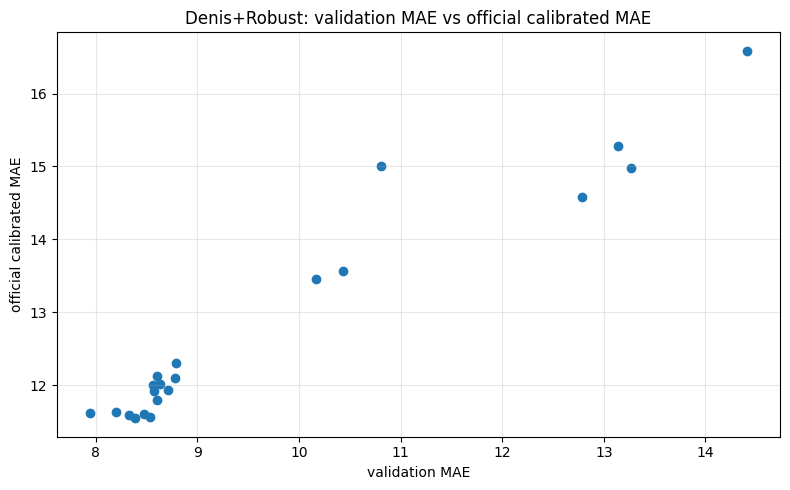

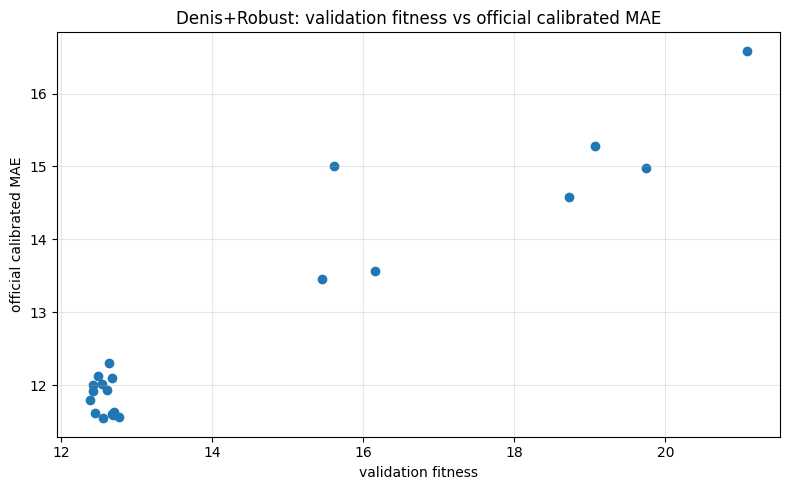

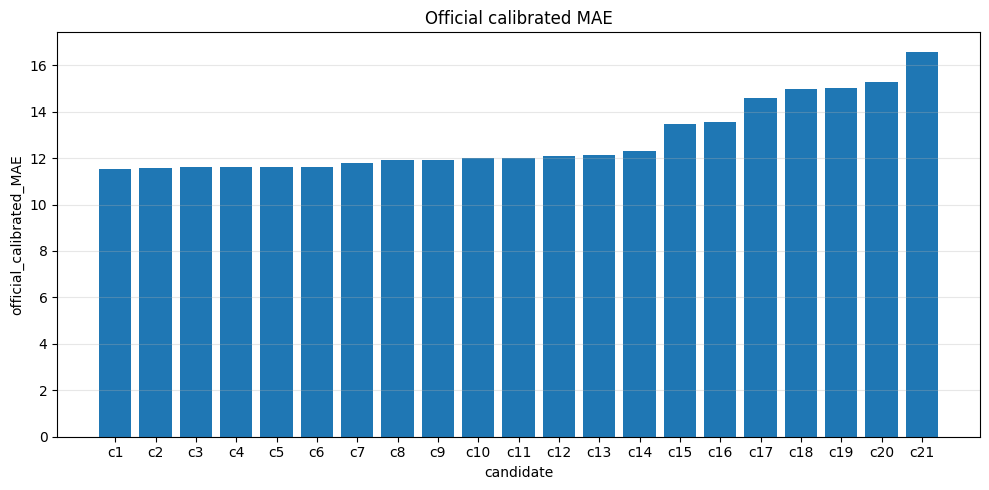

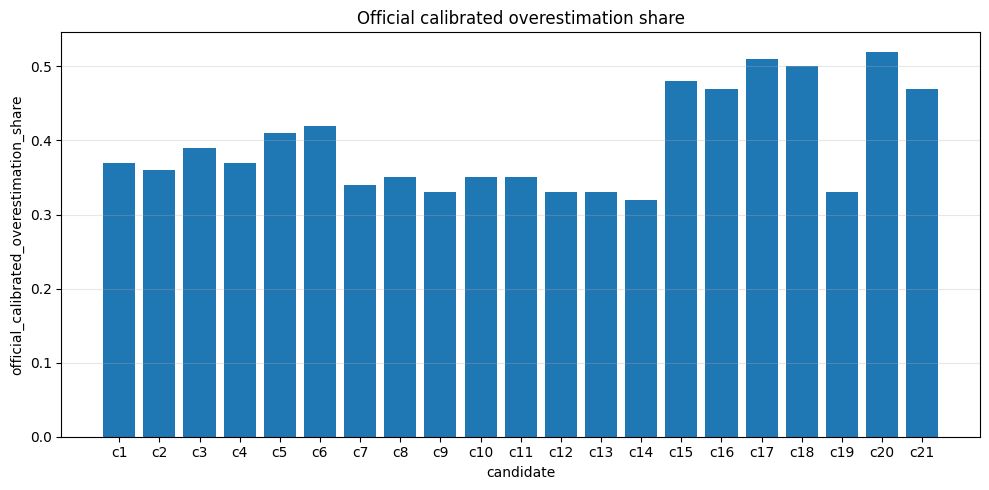

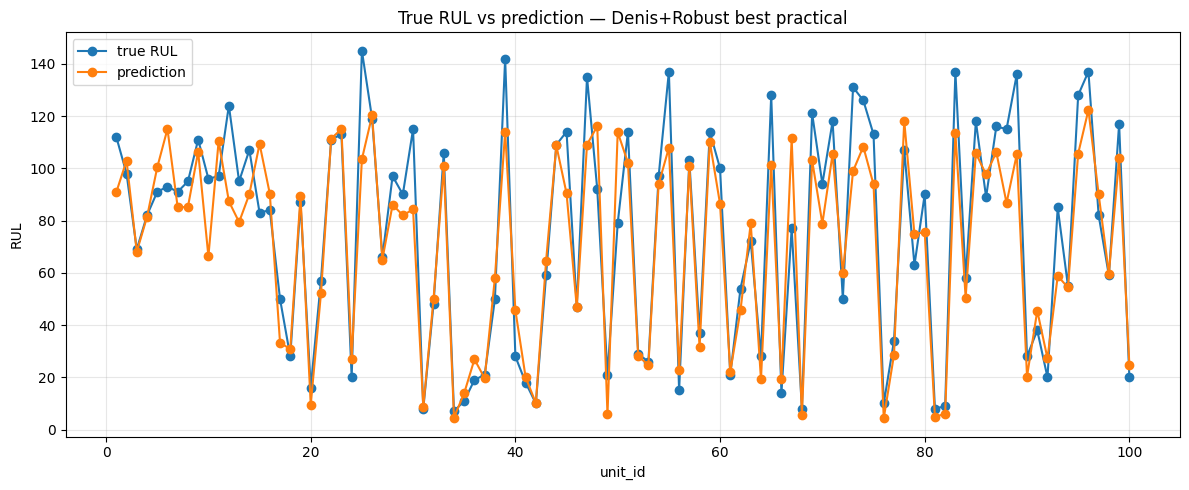

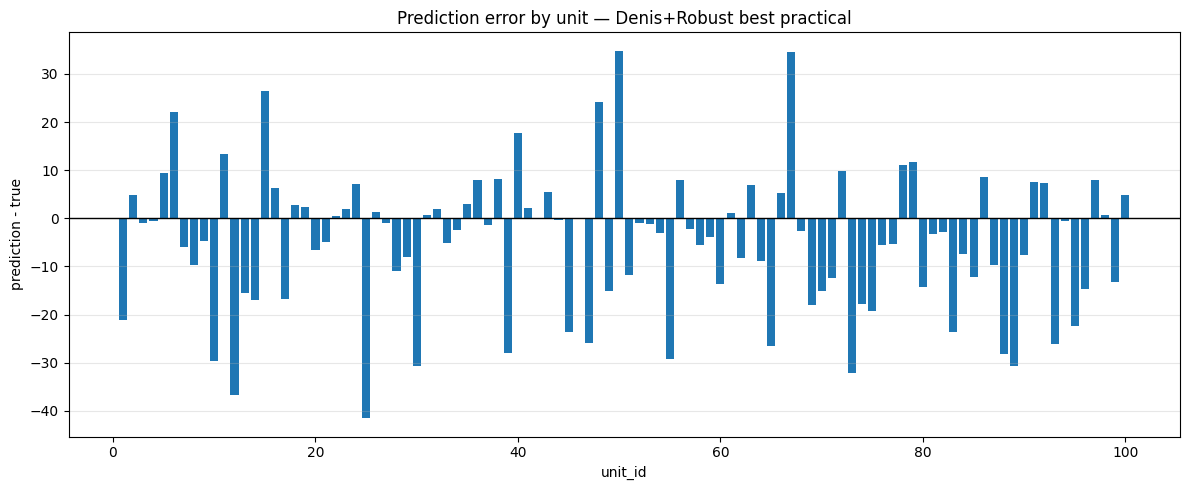

In [15]:
plot_df = official_results_df.reset_index(drop=True).copy()
plot_df["candidate_label"] = [f"c{i+1}" for i in range(len(plot_df))]

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["validation_MAE"], plot_df["official_calibrated_MAE"])
plt.xlabel("validation MAE")
plt.ylabel("official calibrated MAE")
plt.title("Denis+Robust: validation MAE vs official calibrated MAE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["validation_fitness"], plot_df["official_calibrated_MAE"])
plt.xlabel("validation fitness")
plt.ylabel("official calibrated MAE")
plt.title("Denis+Robust: validation fitness vs official calibrated MAE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for metric, title in [
    ("official_calibrated_MAE", "Official calibrated MAE"),
    (
        "official_calibrated_overestimation_share",
        "Official calibrated overestimation share",
    ),
]:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["candidate_label"], plot_df[metric])
    plt.title(title)
    plt.xlabel("candidate")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

practical_hash = best_practical["candidate_hash"]
practical_error_df = error_tables[practical_hash]
plt.figure(figsize=(12, 5))
plt.plot(
    practical_error_df["id"],
    practical_error_df["true_rul"],
    marker="o",
    label="true RUL",
)
plt.plot(
    practical_error_df["id"],
    practical_error_df["pred_rul"],
    marker="o",
    label="prediction",
)
plt.title("True RUL vs prediction — Denis+Robust best practical")
plt.xlabel("unit_id")
plt.ylabel("RUL")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(practical_error_df["id"], practical_error_df["error"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Prediction error by unit — Denis+Robust best practical")
plt.xlabel("unit_id")
plt.ylabel("prediction - true")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Output checklist

In [16]:
expected_files = [
    str(CANDIDATE_RESULTS_CSV),
    str(GENERATION_SUMMARY_CSV),
    str(ROBUSTNESS_LIST_CSV),
    str(OFFICIAL_RESULTS_CSV),
    str(SHIFT_RESULTS_CSV),
    str(VS_WEEK3_CSV),
    str(FINAL_RECOMMENDATIONS_CSV),
]

pd.DataFrame(
    {"file": expected_files, "exists": [Path(file).exists() for file in expected_files]}
)

,file,exists
0,outputs\denis_week4_robust_v2_all_candidate_re...,True
1,outputs\denis_week4_robust_v2_generation_summa...,True
2,outputs\denis_week4_robust_v2_robustness_candi...,True
3,outputs\denis_week4_robust_v2_official_results...,True
4,outputs\denis_week4_robust_v2_shift_results.csv,True
5,outputs\denis_week4_robust_v2_vs_week3_compari...,True
6,outputs\denis_week4_robust_v2_final_recommenda...,True
